<a href="https://colab.research.google.com/github/kevindiaz0802/Regresi-n-logistica/blob/main/Ejercicio_Regre_Logistica_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Sección 1 Colab
Para guardar el archivo en drive se puede hacer uso de la "*funciòn from google.colab import drive*", sin embargo colab tiene su autoguardado por defecto o se puede presionar "*CTRL+S*"

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Documento guardado con exito")

Mounted at /content/drive
Documento guardado con exito


## 2. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay,
                             classification_report, roc_curve,
                             roc_auc_score)



- Pandas organiza los datos en tablas.
- NumPy apoya operaciones numéricas.
- Matplotlib permite visualizar.
- Scikit-learn permite dividir datos, crear el modelo y evaluar sus resultados.


## 3. Subir archivo

In [32]:
from google.colab import drive
drive.mount('/content/drive')          # pide autorización la primera vez

ruta = '/content/drive/MyDrive/Colab Notebooks/14abd612-587a-4c99-bb41-8083c3cb8642.csv'   # ajusta la carpeta y el nombre
df = pd.read_csv(ruta)
print("Filas y columnas:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filas y columnas: (500000, 12)


,codigo_camara,camara_comercio,tipo_sociedad,organizacion_juridica,categoria_matricula,actividad_economica,tipo_persona,antiguedad_empresa,ultimo_ano_renovado,renovo,segmento_antiguedad,anos_sin_renovar
0,4,BOGOTA,SOCIEDAD COMERCIAL,PERSONA NATURAL,PERSONA NATURAL,Confección de prendas de vestir,1,22.0,2024,1,Madura,1
1,4,BOGOTA,SOCIEDAD COMERCIAL,PERSONA NATURAL,PERSONA NATURAL,Comercio al por menor de productos textiles en...,1,25.0,2018,0,Madura,7
2,4,BOGOTA,SOCIEDAD COMERCIAL,SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS,SOCIEDAD ó PERSONA JURIDICA PRINCIPAL ó ESAL,Construcción de otras obras de ingeniería civil.,2,15.0,2010,0,Madura,15
3,8,CALI,SOCIEDAD COMERCIAL,SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS,SOCIEDAD ó PERSONA JURIDICA PRINCIPAL ó ESAL,Actividades de consultaría de gestión.,2,9.0,2017,0,Establecida,8
4,27,PEREIRA,SOCIEDAD COMERCIAL,PERSONA NATURAL,PERSONA NATURAL,Expendio a la mesa de comidas preparadas.,1,2.0,2025,1,Joven,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   codigo_camara          500000 non-null  int64  
 1   camara_comercio        500000 non-null  object 
 2   tipo_sociedad          500000 non-null  object 
 3   organizacion_juridica  499898 non-null  object 
 4   categoria_matricula    500000 non-null  object 
 5   actividad_economica    500000 non-null  object 
 6   tipo_persona           500000 non-null  int64  
 7   antiguedad_empresa     500000 non-null  float64
 8   ultimo_ano_renovado    500000 non-null  int64  
 9   renovo                 500000 non-null  int64  
 10  segmento_antiguedad    500000 non-null  object 
 11  anos_sin_renovar       500000 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 45.8+ MB


In [5]:
print(df.isna().sum())

codigo_camara              0
camara_comercio            0
tipo_sociedad              0
organizacion_juridica    102
categoria_matricula        0
actividad_economica        0
tipo_persona               0
antiguedad_empresa         0
ultimo_ano_renovado        0
renovo                     0
segmento_antiguedad        0
anos_sin_renovar           0
dtype: int64


Se identifican 102 filas vacias de la columna `organizacion_juridica`

In [6]:
df.describe()

,codigo_camara,tipo_persona,antiguedad_empresa,ultimo_ano_renovado,renovo,anos_sin_renovar
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,10.693502,1.375054,9.993362,1871.277584,0.451010,153.722416
std,11.018889,0.484137,8.274630,528.544916,0.497595,528.544916
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.000000,4.000000,2016.000000,0.000000,0.000000
50%,4.000000,1.000000,8.000000,2022.000000,0.000000,3.000000
75%,21.000000,2.000000,14.000000,2025.000000,1.000000,9.000000
max,58.000000,2.000000,2024.000000,2025.000000,1.000000,2025.000000


## 4. Limpieza


In [7]:
# --- Datos imposibles ---
print("Filas con año = 0:", (df['ultimo_ano_renovado'] < 1900).sum())
print("Filas con antigüedad > 100 años:", (df['antiguedad_empresa'] > 100).sum())

df = df[(df['ultimo_ano_renovado'] >= 1900) & (df['antiguedad_empresa'] <= 100)].copy()
df['organizacion_juridica'] = df['organizacion_juridica'].fillna('SIN INFORMACION')
print("Filas después de limpiar:", df.shape[0])

Filas con año = 0: 36938
Filas con antigüedad > 100 años: 2
Filas después de limpiar: 463060


Se liminan filas con año = 0 (año faltante) y con antigüedades atipicas, y rellenan los 102 vacíos de organizacion_juridica.

## 5. Preparación de variables

In [8]:
# Recodificamos tipo_persona: 1 = natural -> 0 y 2 = jurídica -> 1
df['es_juridica'] = (df['tipo_persona'] == 2).astype(int)

variables_X = ['es_juridica', 'antiguedad_empresa', 'camara_comercio',
               'organizacion_juridica']

Esto convierte tipo_persona a `0/1` para que la interpretación sea más clara (1 = jurídica, 0= natural). Esto no cambia el modelo en esencia pero si ayuda al proceso de regresión y analisis

In [9]:
print(df[variables_X + ['renovo']].head())

   es_juridica  antiguedad_empresa camara_comercio  \
0            0                22.0          BOGOTA   
1            0                25.0          BOGOTA   
2            1                15.0          BOGOTA   
3            1                 9.0            CALI   
4            0                 2.0         PEREIRA   

                       organizacion_juridica  renovo  
0                            PERSONA NATURAL       1  
1                            PERSONA NATURAL       0  
2  SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS       0  
3  SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS       0  
4                            PERSONA NATURAL       1  


Renovó será la variable Y

In [10]:
print(df['renovo'].value_counts(normalize=True).round(3))

renovo
0    0.513
1    0.487
Name: proportion, dtype: float64


In [11]:
X = pd.get_dummies(df[variables_X],
                   columns=['camara_comercio', 'organizacion_juridica'],
                   drop_first=True, dtype=int)
y = df['renovo']

Partiendo de la idea de que se va a hacer uso de variables X con columnas que contienen diversa variedad de datos como lo son camara comercio y organización juridica, se procede a realizar el sigueinte procedimiento

La regresión logística solo entiende números, así que `get_dummies` convierte cada cámara y cada tipo de organización en columnas de 0 y 1 (una columna por categoría). `drop_first=True` elimina una categoría de cada variable, que queda como referencia, para evitar columnas redundantes. De 4 variables pasamos a 93 columnas.

In [12]:
print("Tamaño de X:", X.shape)
X.head()

Tamaño de X: (463060, 93)


,es_juridica,antiguedad_empresa,camara_comercio_AGUACHICA,camara_comercio_AMAZONAS,camara_comercio_ARAUCA,camara_comercio_ARMENIA,camara_comercio_BARRANCABERMEJA,camara_comercio_BARRANQUILLA,camara_comercio_BOGOTA,camara_comercio_BUCARAMANGA,...,organizacion_juridica_SIN INFORMACION,organizacion_juridica_SOCIEDAD AGRARIA DE TRANSFORMACIÓN,organizacion_juridica_SOCIEDAD ANONIMA,organizacion_juridica_SOCIEDAD COLECTIVA,organizacion_juridica_SOCIEDAD EN COMANDITA POR ACCIONES,organizacion_juridica_SOCIEDAD EN COMANDITA SIMPLE,organizacion_juridica_SOCIEDAD EXTRANJERA,organizacion_juridica_SOCIEDAD LIMITADA,organizacion_juridica_SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS,organizacion_juridica_VEEDURIA
0,0,22.0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,25.0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,15.0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
3,1,9.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,2.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 6. Graficas

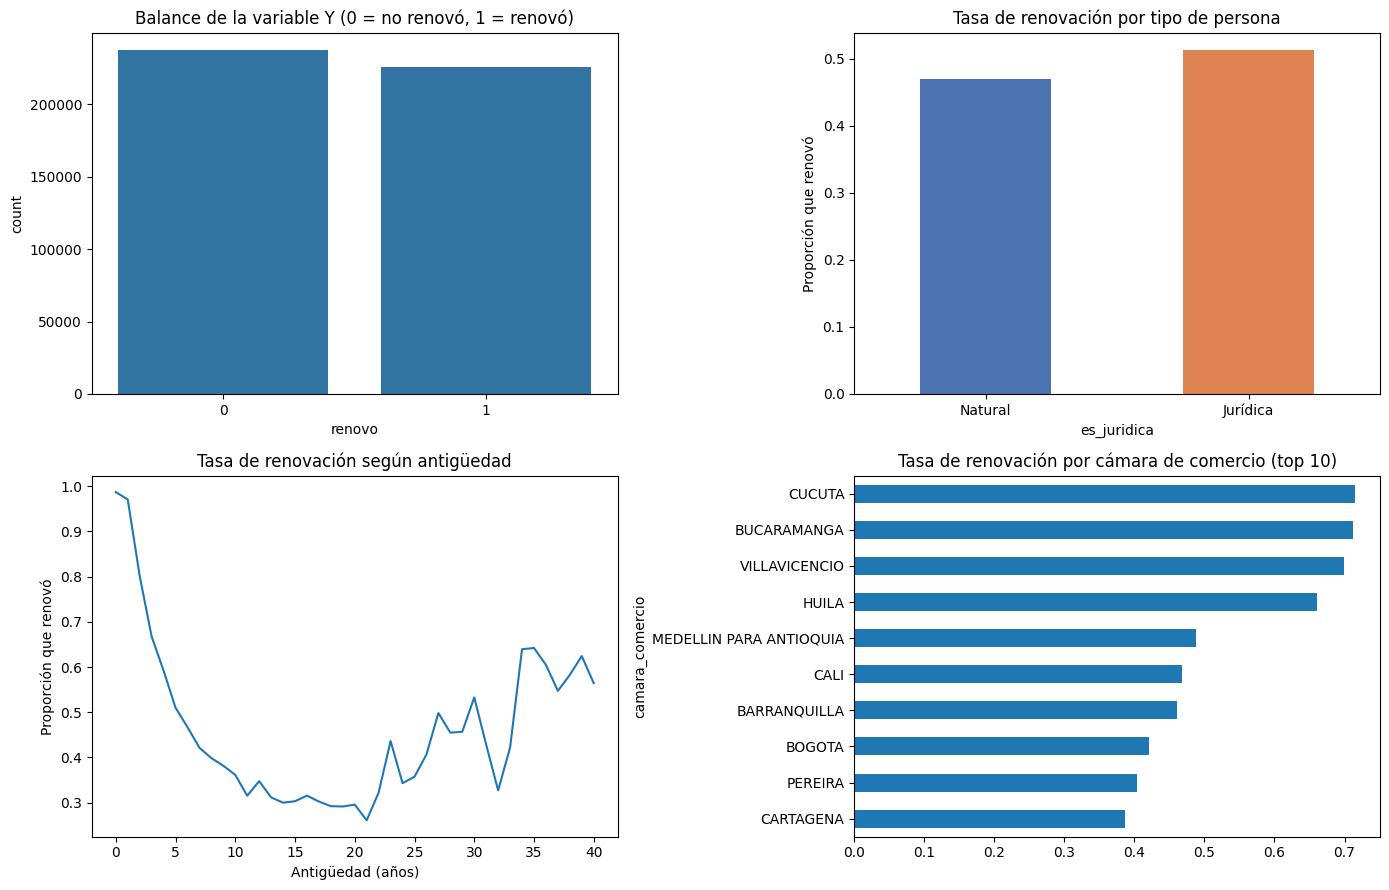

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# 1) Balance de la Y
sns.countplot(x='renovo', data=df, ax=ax[0, 0])
ax[0, 0].set_title('Balance de la variable Y (0 = no renovó, 1 = renovó)')

# 2) Tasa de renovación por tipo de persona
df.groupby('es_juridica')['renovo'].mean().plot(kind='bar', ax=ax[0, 1], color=['#4C72B0', '#DD8452'])
ax[0, 1].set_xticklabels(['Natural', 'Jurídica'], rotation=0)
ax[0, 1].set_title('Tasa de renovación por tipo de persona'); ax[0, 1].set_ylabel('Proporción que renovó')

# 3) Tasa de renovación según la antigüedad (se agrupa de 40 años en adelante)
df.groupby(df['antiguedad_empresa'].clip(upper=40))['renovo'].mean().plot(ax=ax[1, 0])
ax[1, 0].set_title('Tasa de renovación según antigüedad')
ax[1, 0].set_xlabel('Antigüedad (años)'); ax[1, 0].set_ylabel('Proporción que renovó')

# 4) Tasa de renovación en las 10 cámaras con más empresas
top = df['camara_comercio'].value_counts().head(10).index
df[df['camara_comercio'].isin(top)].groupby('camara_comercio')['renovo'].mean().sort_values().plot(kind='barh', ax=ax[1, 1])
ax[1, 1].set_title('Tasa de renovación por cámara de comercio (top 10)')

plt.tight_layout(); plt.show()

El `(2, 2)` significa 2 filas y 2 columnas, y `figsize`=(14, 9) es el tamaño en pulgadas (ancho, alto).
Con varios recuadros, `ax` funciona como una tabla y cada recuadro se identifica con [fila, columna]. Python empieza a contar desde 0, no desde 1:

Como observación se puede identifcar:
- Existe una mayor tendencia de norenovación por parte de las empresas, sin
embargo estan muy cerca del 50%
- Las jurídicas renuevan más (51 %) que las naturales (47 %).
- Las empresas nuevas renuevan casi todas y se identifica que las que tienen entre 20 y 25 años son las que menos recurren a renovar la matriucla
- Las cámaras difieren bastante entre sí, cucuta y bucaramanga tienen la
proporción de que de 100 empresas, 71 de ellas renuvean su registro

## 7. Dividir en entrenamiento y prueba

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("% que renovó en entrenamiento:", round(y_train.mean(), 3), "| en prueba:", round(y_test.mean(), 3))

Entrenamiento: (370448, 93) | Prueba: (92612, 93)
% que renovó en entrenamiento: 0.487 | en prueba: 0.487


- Separa el 80 % de los datos para que el modelo aprenda (370.448 filas) y el 20 % para evaluarlo (92.612 filas) con datos que nunca vio.
- random_state=42 hace que el resultado sea repetible.
- stratify=y mantiene la misma proporción de 0 y 1 en ambos grupos (48,7 % en los dos).

## 8. Crear y entrenar el modelo

In [15]:
modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

La primera línea crea el modelo vacío y max_iter=2000 le da suficientes intentos para converger.

`fit()` lo entrena: busca los coeficientes (pesos) de cada variable que mejor separan las empresas que renovaron de las que no.

In [16]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

pd.DataFrame({'real': y_test.values[:10],
              'prediccion': y_pred[:10],
              'prob_renovar': y_prob[:10].round(3)})

,real,prediccion,prob_renovar
0,0,0,0.472
1,0,0,0.384
2,0,0,0.215
3,0,1,0.526
4,1,0,0.492
5,1,0,0.353
6,0,1,0.632
7,1,1,0.769
8,1,1,0.702
9,0,0,0.487


El modelo predice sobre el 20 % de prueba. `predict()` devuelve la decisión final (0 o 1) y `predict_proba()` devuelve la probabilidad de renovar.

La tabla compara las primeras 10 empresas:
por ejemplo, la fila 3 tiene probabilidad 0,526, así que el modelo dice "renovó" pero en realidad no renovó.

## 9. Metricas de evaluación

In [17]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisión: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}\n")

Accuracy : 0.7019
Precisión: 0.7007
Recall   : 0.6773
F1-Score : 0.6888
AUC-ROC  : 0.7380



### Resultados:

- Accuracy	0.7021 =	De cada 100 empresas, acierta en 70
- Precisión	0.7008 =	Cuando dice "renovará", acierta el 70 % de las veces
- Recall	0.6777 =	Detecta al 68 % de las que realmente renovaron
- F1-Score	0.6890 = Promedio armónico entre precisión y recall
- AUC-ROC	0.7378 =	Probabilidad de que una empresa que renovó reciba una probabilidad más alta que una que no

In [18]:
print(classification_report(y_test, y_pred, target_names=['No renovó', 'Renovó']))

              precision    recall  f1-score   support

   No renovó       0.70      0.73      0.71     47511
      Renovó       0.70      0.68      0.69     45101

    accuracy                           0.70     92612
   macro avg       0.70      0.70      0.70     92612
weighted avg       0.70      0.70      0.70     92612



El recall de "No renovó" (0,73) supera al de "Renovó" (0,68). Por lo tanto el modelo deja pasar menos empresas que abandonan que empresas que renuevan.

### Matriz de confusión

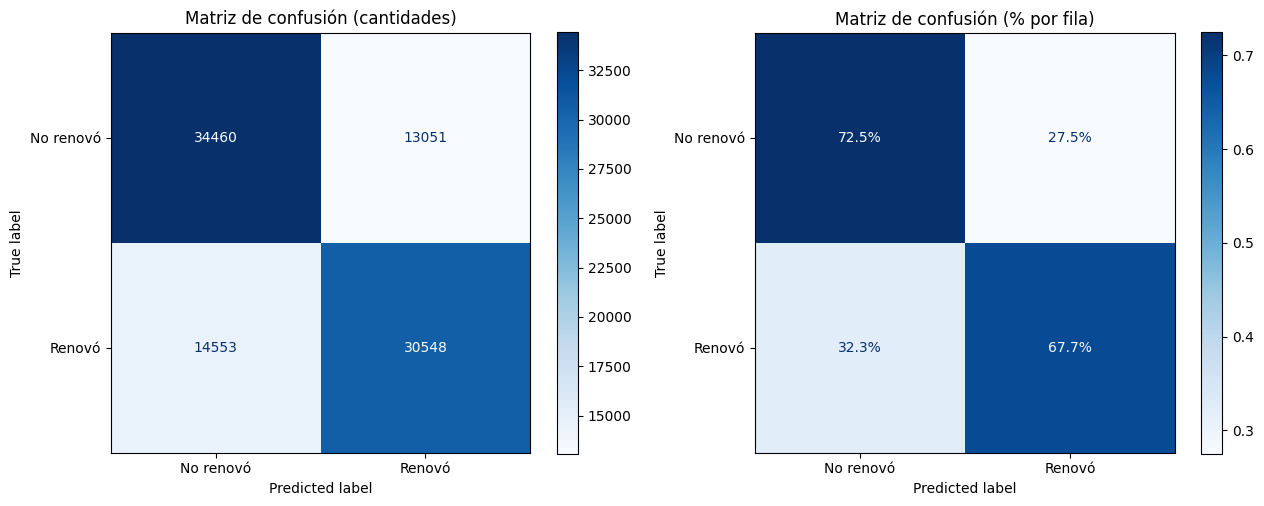

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No renovó', 'Renovó'],
                                        cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de confusión (cantidades)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No renovó', 'Renovó'],
                                        cmap='Blues', normalize='true', values_format='.1%', ax=ax[1])
ax[1].set_title('Matriz de confusión (% por fila)')
plt.tight_layout(); plt.show()

La grafica de la izquierda representa estos resultados

- Realmente no renovó

34.460 (verdaderos negativos)	13.051 (falsos positivos)

- Realmente renovó

14.538 (falsos negativos)	30.563 (verdaderos positivos)

La grafica de la izquierda representa estos resultados:
Cada cantidad se divide entre el total de su fila (normalize='true'). Así cada fila suma 100 %:
- Realmente no renovó

34.460 / 47.511 = 72,5 %

13.051 / 47.511 = 27,5 %

- Realmente renovó

14.538 / 45.101 = 32,2 %

30.563 / 45.101 = 67,8 %

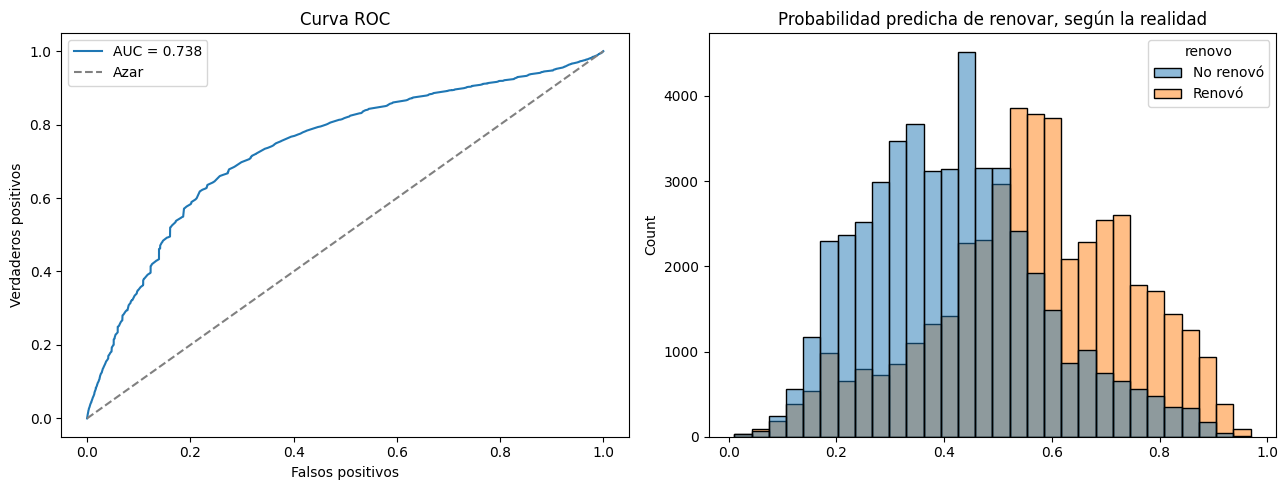

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax[0].plot([0, 1], [0, 1], '--', color='gray', label='Azar')
ax[0].set_title('Curva ROC'); ax[0].set_xlabel('Falsos positivos'); ax[0].set_ylabel('Verdaderos positivos')
ax[0].legend()

sns.histplot(x=y_prob, hue=y_test.map({0: 'No renovó', 1: 'Renovó'}), bins=30, ax=ax[1])
ax[1].set_title('Probabilidad predicha de renovar, según la realidad')
plt.tight_layout(); plt.show()

- La curva ROC muestra qué tan bien separa el modelo a las dos clases. Entre más se aleja de la diagonal (el azar), mejor.
- El histograma muestra que las que renovaron tienden a tener probabilidades más altas, pero con traslape. Ese traslape es la razón de que el modelo acierte "solo" el 70 %.

### ODDS

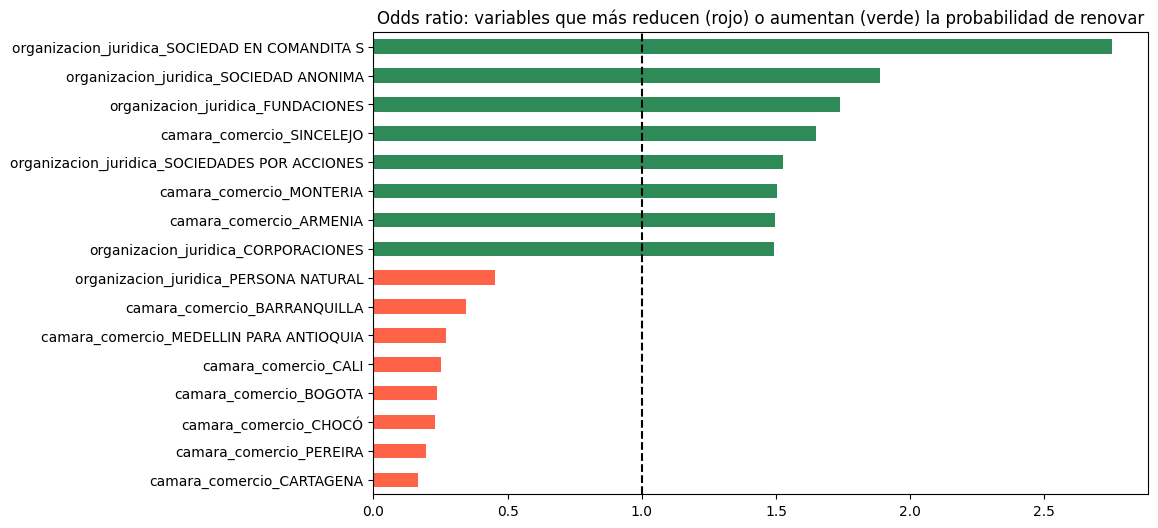

Odds ratio de la antigüedad: 0.924


In [21]:
coef = pd.Series(modelo.coef_[0], index=X.columns)
odds = np.exp(coef)                                      # odds ratio = e^coeficiente

frecuentes = X.columns[X.sum() >= 1000]                  # ignora categorías muy raras (inestables)
odds = odds[frecuentes].sort_values()
extremos = pd.concat([odds.head(8), odds.tail(8)])       # los 8 más bajos y los 8 más altos
extremos.index = [i[:45] for i in extremos.index]        # acorta los nombres largos

extremos.plot(kind='barh', figsize=(10, 6), color=list(np.where(extremos < 1, 'tomato', 'seagreen')))
plt.axvline(1, color='black', linestyle='--')
plt.title('Odds ratio: variables que más reducen (rojo) o aumentan (verde) la probabilidad de renovar')
plt.show()

print("Odds ratio de la antigüedad:", round(odds['antiguedad_empresa'], 3))

Con esta grafica se pretende indentificar las variables mas significativas del ejercicio y las menos significativas en un top 8, ignorando categorias muy raras
- Un odds ratio mayor a 1 aumenta la probabilidad de renovar y uno menor a 1 la reduce.

## 10. Umbral de decisión

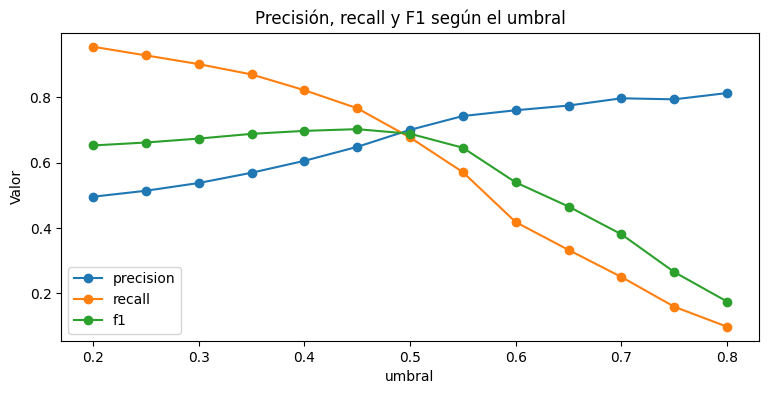

,umbral,precision,recall,f1
0,0.20,0.496,0.955,0.653
1,0.25,0.514,0.929,0.662
2,0.30,0.538,0.902,0.674
3,0.35,0.569,0.870,0.688
4,0.40,0.606,0.822,0.698
5,0.45,0.649,0.767,0.703
6,0.50,0.701,0.677,0.689
7,0.55,0.743,0.571,0.646
8,0.60,0.761,0.418,0.540
9,0.65,0.775,0.333,0.466


In [22]:
resultados = []
for u in np.arange(0.2, 0.81, 0.05):
    pred_u = (y_prob >= u).astype(int)
    resultados.append([round(u, 2), precision_score(y_test, pred_u),
                       recall_score(y_test, pred_u), f1_score(y_test, pred_u)])

tabla = pd.DataFrame(resultados, columns=['umbral', 'precision', 'recall', 'f1'])
tabla.plot(x='umbral', y=['precision', 'recall', 'f1'], marker='o', figsize=(9, 4))
plt.title('Precisión, recall y F1 según el umbral'); plt.ylabel('Valor'); plt.show()
tabla.round(3)

Subir el umbral aumenta la precisión (0,70 a 0,5 y 0,80 a 0,7) pero baja el recall (0,68 a 0,5 y 0,25 a 0,7). Aquí el mejor F1 aparece cerca de 0,45 (≈0,702, frente a 0,689 con 0,5).

## 11. Predicción de una empresa nueva

In [23]:
nueva = pd.DataFrame(0, index=[0], columns=X.columns)
nueva['antiguedad_empresa'] = 5
nueva['es_juridica'] = 1
nueva['camara_comercio_BOGOTA'] = 1
nueva['organizacion_juridica_SOCIEDADES POR ACCIONES SIMPLIFICADAS SAS'] = 1

print("Probabilidad de renovar:", round(modelo.predict_proba(nueva)[0, 1], 3))
print("Predicción:", modelo.predict(nueva)[0])

Probabilidad de renovar: 0.632
Predicción: 1


A manera de practica simulamos una SAS de Bogotá con 5 años y calcula su probabilidad de renovar: 63,2 %, por lo que la predicción es 1 (renueva).